In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv("mail_data.csv")

In [4]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.shape

(5572, 2)

In [6]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
df.columns

Index(['Category', 'Message'], dtype='object')

In [8]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [9]:
df.rename(columns={'Category':'label'},inplace=True)

In [10]:
df.head()

,label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
df.drop_duplicates(subset='Message',inplace=True)

In [12]:
df

,label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [13]:
df['label'].value_counts()

label
ham     4516
spam     641
Name: count, dtype: int64

In [14]:
df['length']=df['Message'].apply(len)

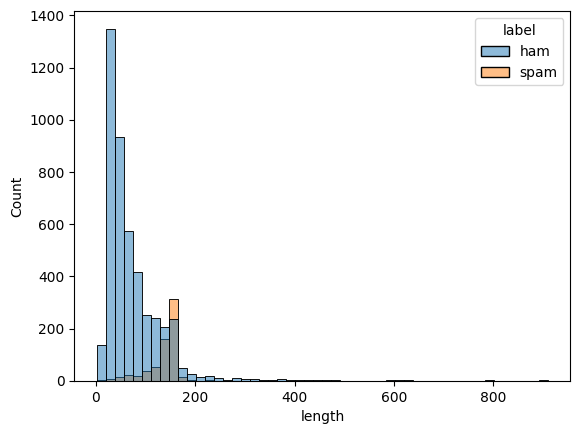

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data=df,x='length',hue='label',bins=50)
plt.show()

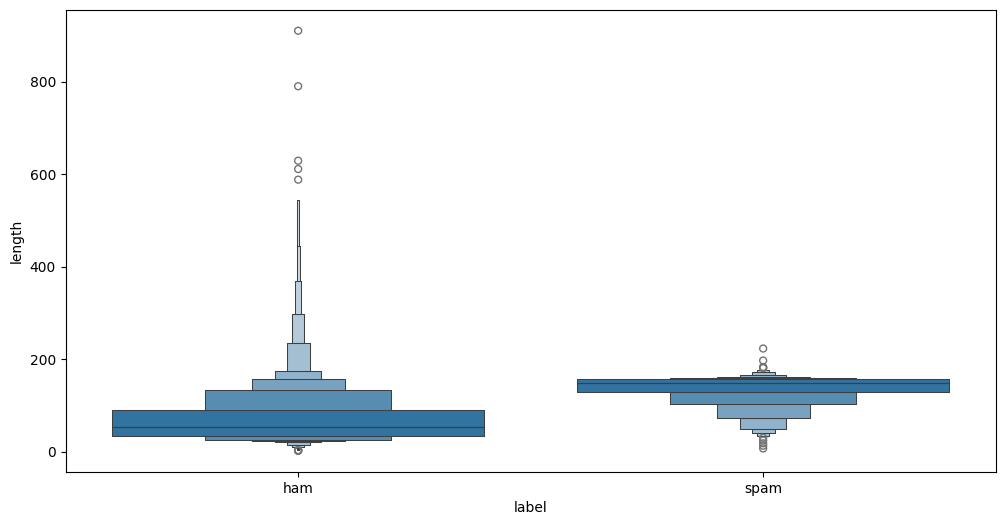

In [33]:
plt.figure(figsize=(12,6))
sns.boxenplot(x='label',y='length',data=df)
plt.show()

In [16]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stopwords=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

def preprocessing(text):
    text=text.lower()
    text=re.sub(r'[^a-zA-Z]',' ',text)
    words=word_tokenize(text)
    words=[word for word in words if word not in stopwords]
    words=[lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)
    
    

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vinot\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vinot\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vinot\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [17]:
df['text']=df['Message'].apply(preprocessing)

In [18]:
df.head()

,label,Message,length,text
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah think go usf life around though


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

X_train,X_test,y_train,y_test=train_test_split(df['text'],df['label'],stratify=df['label'],test_size=0.2,random_state=42)

svm=SVC(class_weight='balanced',kernel='sigmoid',)
mnb=MultinomialNB()
lr=LogisticRegression(class_weight='balanced')


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=5000)
X_train_vec=tfidf.fit_transform(X_train)
X_test_vec=tfidf.transform(X_test)

In [21]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_res,y_train_res=smote.fit_resample(X_train_vec,y_train)

In [22]:
model1=svm.fit(X_train_res,y_train_res)
model2=mnb.fit(X_train_res,y_train_res)
model3=lr.fit(X_train_res,y_train_res)

In [23]:
pred1=model1.predict(X_test_vec)
pred2=model2.predict(X_test_vec)
pred3=model3.predict(X_test_vec)

In [24]:
y_prob=model2.predict_proba(X_test_vec)[:,1]


In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred1))
print(classification_report(y_test,pred2))
print(classification_report(y_test,pred3))

              precision    recall  f1-score   support

         ham       0.98      0.97      0.98       904
        spam       0.81      0.88      0.84       128

    accuracy                           0.96      1032
   macro avg       0.90      0.92      0.91      1032
weighted avg       0.96      0.96      0.96      1032

              precision    recall  f1-score   support

         ham       0.99      0.96      0.97       904
        spam       0.75      0.91      0.83       128

    accuracy                           0.95      1032
   macro avg       0.87      0.94      0.90      1032
weighted avg       0.96      0.95      0.95      1032

              precision    recall  f1-score   support

         ham       0.99      0.98      0.98       904
        spam       0.86      0.90      0.88       128

    accuracy                           0.97      1032
   macro avg       0.93      0.94      0.93      1032
weighted avg       0.97      0.97      0.97      1032



In [26]:
model3.classes_

array(['ham', 'spam'], dtype=object)

In [27]:
def predict_spam1(text):
    text = preprocessing(text)
    vec = tfidf.transform([text])
    return model1.predict(vec)[0]

In [28]:
def predict_spam2(text):
    text = preprocessing(text)
    vec = tfidf.transform([text])
    return model2.predict(vec)[0]

In [29]:
def classify(prob):
    if prob>0.75:
        return "spam"
    if prob<0.75 and prob>0.40:
        return "suspicious"
    elif prob<0.40:
        return "ham"
    
def predict_spam3(text):
    text = preprocessing(text)
    vec = tfidf.transform([text])
    prob=model3.predict_proba(vec)[0][1]
    label=classify(prob)
    return prob,label
    


In [30]:
prob,label=predict_spam3("""  mixed_cases = [
    "Hey, I sent you the Google Meet link, join soon",
    "Update your account information to avoid issues",
    "Are you attending the internship interview tomorrow?",
    "Click here to verify your account immediately",
    "Your salary has been credited successfully",
    "Win rewards by completing this quick survey",
    "Bro, check your mail I sent the document",
    "Final reminder: claim your reward before expiry",
    "Your package will be delivered tomorrow",
    "Urgent: action required for your account"
]
""")
print(prob)
print(label)

0.635391272295844
suspicious
